In [ ]:
!pip install tensorflow
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.20.0
[]


In [ ]:
# Basic libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
dataset = pd.read_csv("Churn_Modelling.csv")
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
## Divide the dataset into independant and dependant features

x = dataset.iloc[:, 3:13]
y = dataset.iloc[:,13]

In [ ]:
x.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [ ]:
## Feature engineering

geo = pd.get_dummies(x["Geography"], drop_first=True) # Python function used to convert categorical variables into dummy (indicator) variables, a process known as one-hot encoding.
gender = pd.get_dummies(x["Gender"], drop_first=True)

In [ ]:
# Concatenate these variables with dataframes

x = x.drop(["Geography", "Gender"], axis=1) # axis=1: for dropping the columns

In [ ]:
x = pd.concat([x, geo, gender], axis=1)
x.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False


In [ ]:
# Splitting the dataset into training set and testing set
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size= 0.2, random_state=0)
# test_size controls what fraction of your data is held out for testing. With test_size=0.2, 20% of the rows go into X_test / Y_test, and the remaining 80% go into X_train / Y_train.

In [ ]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
X_train.shape

(8000, 11)

In [ ]:
## Lets create an ANN

from tensorflow.keras.models import Sequential # a container that lets you build a neural network by stacking layers one after another.
from tensorflow.keras.layers import Dense # a fully connected layer where every neuron is linked to all neurons in the previous layer (the main building block).
from tensorflow.keras.layers import LeakyReLU, PReLU, ELU, ReLU
"""
- LeakyReLU: an activation that passes positive values as-is and lets a tiny slope through for negatives, so neurons don't "die".
- PReLU: like LeakyReLU, but the slope for negative values is learned by the model instead of being fixed.
- ELU: an activation that smoothly curves negative values toward a small negative number instead of cutting them to zero.
- ReLU: the classic activation that turns all negative values into 0 and keeps positive values unchanged.
"""
from tensorflow.keras.layers import Dropout # randomly switches off some neurons during training so the model doesn't memorize the data (reduces overfitting).

In [ ]:
## Initalizing the ANN

classifier= Sequential()

In [ ]:
## Adding the input layer

classifier.add(Dense(units=11, activation="relu"))

In [ ]:
## Adding first hidden layer

classifier.add(Dense(units=7, activation="relu"))

In [ ]:
## Adding the second hidden layer

classifier.add(Dense(units=6, activation="relu"))

In [ ]:
## Adding the output layer

classifier.add(Dense(1, activation="sigmoid"))

In [ ]:
import tensorflow

# creates the optimizer, which is the algorithm that adjusts the weights; the learning rate is how big each adjustment step is.
opt= tensorflow.keras.optimizers.Adam(learning_rate= 0.001)

In [ ]:
classifier.compile(optimizer=opt, loss="binary_crossentropy", metrics=["accuracy"]) # sets up training by choosing the optimizer

In [ ]:
# Early stopping: Stop training when the monitored metric has stopped improving

import tensorflow as tf
early_stopping= tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=30,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)

In [ ]:
model_history= classifier.fit(X_train, Y_train, validation_split= 0.33, batch_size=10, epochs= 1000, callbacks= early_stopping)

"""
- validation_split=0.33: holds back 33% of the training data to check performance after each epoch.
- batch_size=10: updates the weights after every 10 rows.
- epochs=1000: goes through the full dataset 1000 times.
"""

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7858 - loss: 0.4932 - val_accuracy: 0.7955 - val_loss: 0.4603
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8018 - loss: 0.4377 - val_accuracy: 0.8118 - val_loss: 0.4340
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8261 - loss: 0.4129 - val_accuracy: 0.8201 - val_loss: 0.4130
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8360 - loss: 0.3912 - val_accuracy: 0.8289 - val_loss: 0.3950
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8446 - loss: 0.3706 - val_accuracy: 0.8315 - val_loss: 0.3869
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8494 - loss: 0.3577 - val_accuracy: 0.8432 - val_loss: 0.3769
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8531 - loss: 0.3498 - val_accuracy: 0.8440 - val_loss: 0.3759
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8584 - loss: 0.3438 

'\n- validation_split=0.33: holds back 33% of the training data to check performance after each epoch.\n- batch_size=10: updates the weights after every 10 rows.\n- epochs=1000: goes through the full dataset 1000 times.\n'

In [ ]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

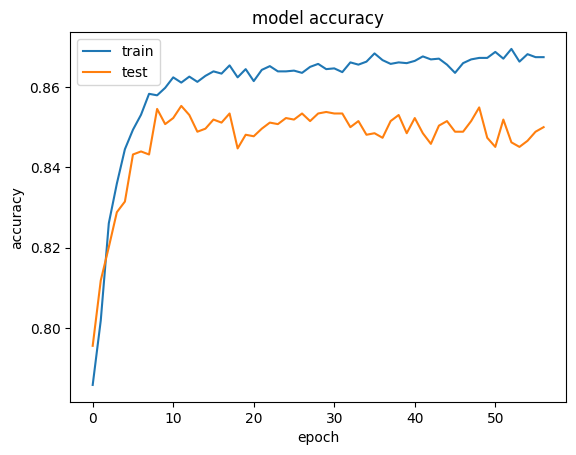

In [ ]:
# summarize history for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

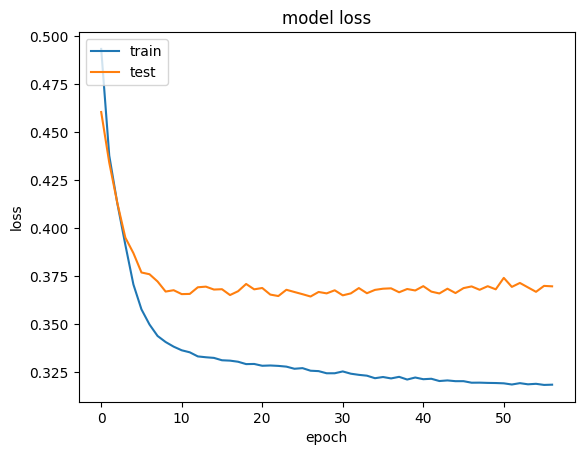

In [ ]:
# summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [ ]:
# Part 3: Making the predictions and evaluating the model

y_pred = classifier.predict(X_test)
y_pred = (y_pred >= 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [ ]:
# Make the confusion matrix

from sklearn.metrics import confusion_matrix # A confusion matrix is a small table that shows how many predictions your model got right and wrong, and what kind of mistakes it made.
cm = confusion_matrix(Y_test, y_pred)
cm

array([[1539,   56],
       [ 219,  186]])

In [ ]:
# Calculating the accuracy

from sklearn.metrics import accuracy_score
score= accuracy_score(y_pred, Y_test)

In [ ]:
score

0.8625

In [ ]:
# Getting the weights

classifier.get_weights()

[array([[-5.18079065e-02,  2.57333438e-03,  7.71908313e-02,
         -5.46047390e-01,  3.62545013e-01,  1.09719872e-01,
         -5.91157734e-01, -1.80310696e-01,  1.28207356e-01,
         -2.38033205e-01, -3.33059072e-01],
        [-8.00824821e-01,  2.42137015e-01, -8.61431751e-03,
          3.12996626e-01, -9.87918675e-01,  3.33718598e-01,
          1.76146865e-01, -3.05831641e-01,  3.24994385e-01,
         -1.18861997e+00,  1.00325012e+00],
        [-3.99375819e-02, -2.38560792e-02, -1.01963222e-01,
          8.09698179e-02, -2.47141674e-01, -1.98781088e-01,
          2.13298172e-01,  4.57791418e-01,  2.64444351e-01,
          1.46532431e-01, -1.92057550e-01],
        [-2.78483659e-01, -1.12621531e-01, -4.79424357e-01,
         -6.33058995e-02,  2.09292442e-01, -4.50226128e-01,
          2.41935149e-01, -1.70205876e-01, -7.77397394e-01,
          5.48813820e-01,  1.12442195e-01],
        [ 1.70111895e-01,  1.02007997e+00, -1.21174455e+00,
         -3.51644270e-02, -2.48413518e-01,  